# Selection des features

## Importation des bibliothèques

In [1]:
import pandas as pd
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

## Préparation des données traitées

In [2]:
df = pd.read_csv("../data/processed/processed_data.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9862 entries, 0 to 9861
Data columns (total 41 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   op_unique_carrier    9862 non-null   int64  
 1   op_carrier_fl_num    9862 non-null   float64
 2   origin               9862 non-null   int64  
 3   origin_city_name     9862 non-null   int64  
 4   origin_state_nm      9862 non-null   int64  
 5   dest                 9862 non-null   int64  
 6   dest_city_name       9862 non-null   int64  
 7   dest_state_nm        9862 non-null   int64  
 8   dep_delay            9862 non-null   float64
 9   taxi_out             9862 non-null   float64
 10  taxi_in              9862 non-null   float64
 11  arr_delay            9862 non-null   float64
 12  cancelled            9862 non-null   int64  
 13  diverted             9862 non-null   int64  
 14  crs_elapsed_time     9862 non-null   float64
 15  actual_elapsed_time  9862 non-null   f

In [4]:
post_flight_features = ['dep_delay', 'nas_delay', 'carrier_delay', 'late_aircraft_delay', 'taxi_out', 'taxi_in', 'weather_delay', 'air_time', 'actual_elapsed_time', 'arr_hour', 'arr_min', 'wheels_on_hour', 'wheels_on_min', 'wheels_off_hour', 'wheels_off_min', 'security_delay', 'diverted', 'cancelled']

df_preflight = df.drop(columns=post_flight_features)

df_preflight.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9862 entries, 0 to 9861
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   op_unique_carrier  9862 non-null   int64  
 1   op_carrier_fl_num  9862 non-null   float64
 2   origin             9862 non-null   int64  
 3   origin_city_name   9862 non-null   int64  
 4   origin_state_nm    9862 non-null   int64  
 5   dest               9862 non-null   int64  
 6   dest_city_name     9862 non-null   int64  
 7   dest_state_nm      9862 non-null   int64  
 8   arr_delay          9862 non-null   float64
 9   crs_elapsed_time   9862 non-null   float64
 10  distance           9862 non-null   float64
 11  fl_year            9862 non-null   int64  
 12  fl_month           9862 non-null   int64  
 13  fl_day             9862 non-null   int64  
 14  fl_dayofweek       9862 non-null   int64  
 15  is_weekend         9862 non-null   int64  
 16  season             9862 

Dans cette partie, nous avons choisi de dresser une liste des features qui ne nous intéressent pas pour prédire les retards de vol, afin de ne pas affecter les résultats de la sélection des features, car ce sont des features définies après le vol. Dans notre contexte, nous souhaitons pouvoir prédire les retards à partir des données disponibles avant le vol.

In [5]:
# matrice des features
X = df_preflight.drop(columns=["arr_delay"], axis=1)
# variable cible -> celle que l'on veut prédire
# Transformation de la variable cible en binaire: 1 = delayed, 0 = not delayed
y = (df_preflight["arr_delay"]>0).astype(int)


Dans cette étape, nous séparons nos données en deux ensembles : les variables explicatives et la variable cible. La matrice X regroupe l’ensemble des caractéristiques descriptives des vols qui serviront de données d’entrée au modèle. Nous retirons la colonne arr_delay de X, car c’est justement la variable que nous cherchons à prédire.
La variable y correspond à la cible du modèle, c’est-à-dire le retard réel à l’arrivée. Comme nous voulons formuler le problème sous forme de classification binaire, nous transformons arr_delay en une variable logique : la valeur 1 indique un vol en retard (arr_delay > 0) et la valeur 0 indique un vol à l’heure ou en avance.
Cette distinction permet au modèle d’apprendre à reconnaître les situations qui mènent à un retard à partir des informations disponibles avant le vol.

## Séparation des données de test et d'entraînement

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

## Entraînement d'un modèle Random Forest (avant la selection des features)

In [7]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Evaluer le modèle
accuracy_before = rf.score(X_test, y_test)
print(f'Accuracy before feature selection: {accuracy_before:.2f}')

Accuracy before feature selection: 0.76


Avant de sélectionner nos features, nous avons lancé le premier entraînement du modèle, qui nous a apporté une accuracy de 76 %.

## Extraction des features importantes

              feature  importance
18           dep_hour    0.082961
19            dep_min    0.070953
17        crs_dep_min    0.066255
16       crs_dep_hour    0.064974
1   op_carrier_fl_num    0.063867
8    crs_elapsed_time    0.056904
9            distance    0.056787
21        crs_arr_min    0.052725
12             fl_day    0.051648
20       crs_arr_hour    0.047080
6      dest_city_name    0.046560
5                dest    0.045621
2              origin    0.045540
3    origin_city_name    0.043134
11           fl_month    0.040221
4     origin_state_nm    0.040145
7       dest_state_nm    0.039447
0   op_unique_carrier    0.032168
13       fl_dayofweek    0.030580
15             season    0.015206
14         is_weekend    0.007226
10            fl_year    0.000000


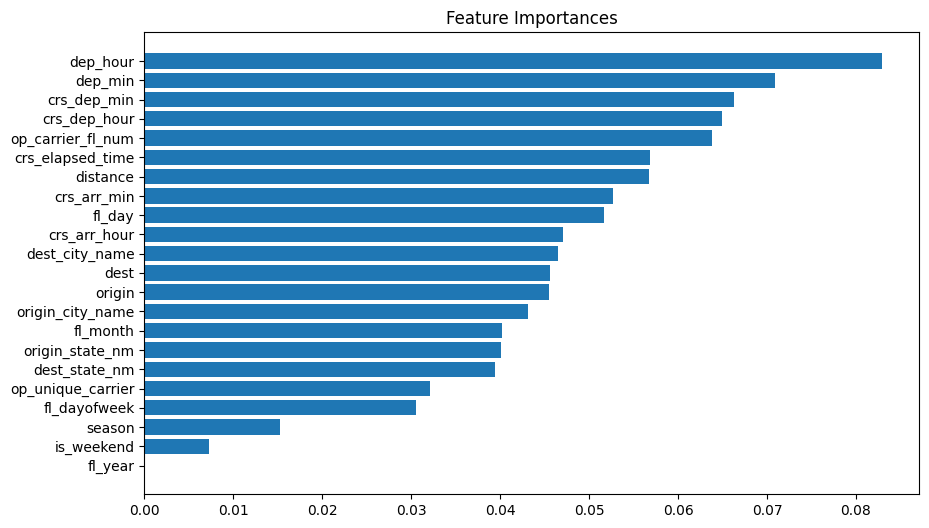

In [8]:
# Classement des features par ordre d'importance
feature_importances = pd.DataFrame({
    'feature' : X_train.columns,
    'importance' : rf.feature_importances_}).sort_values(by='importance', ascending=False)

print(feature_importances)

# Visualiser les top features
plt.figure(figsize=(10,6))
plt.barh(feature_importances['feature'], feature_importances['importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importances")
plt.show()

Ensuite, nous avons trié l’importance de chaque feature afin de visualiser ces résultats dans un graphique plus descriptif. On remarque que les variables 'fl_year' et 'is_weekend' ont un pourcentage d’importance très faible (voire nul) par rapport aux autres features.

##

## Selection des top features

In [9]:
selected_features = feature_importances[feature_importances['importance']>0.01]['feature']
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]


Pour réduire le nombre de variables tout en conservant les plus pertinentes, nous utilisons la méthode feature_importances_ du modèle Random Forest.
Seules les features dont l’importance dépasse 1 % (0.01) sont conservées pour l’entraînement du modèle final.

# Entraînement du modèle Random Forest (après selection des features)

In [10]:
rf_selected = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selected.fit(X_train_selected, y_train)

#Evauation du modèle
accuracy_after = rf_selected.score(X_test_selected, y_test)
print(f'Accuracy after feature selection : {accuracy_after : .2f}')


Accuracy after feature selection :  0.78


Avant et après la selection des features, il y a une différence légère de précision du modèle. Le modèle avec les features selectionnées a 0.01 de précision en plus.  

## Recherche d'un modèle plus performant

In [11]:

# Création grille de test pour tester davantage le modèle et prévenir de l'overfit
param_grid = {
    #nombre d'arbres
    'n_estimators' : [100, 200],
    #Profondeur
    'max_depth' : [12, 15, 20, None],
    # Nb minimum d'exemple par noeud
    'min_samples_split' : [2, 5, 10],
    # Nb minimal d'observations que contient une feuille
    'min_samples_leaf' : [1, 2, 4],
    # Nombre maximal de features considérées à chaque division
    'max_features' : ['sqrt', 'log2']

}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42),
                           param_grid,
                           cv = 3,
                           scoring='accuracy',
                           n_jobs=-1)
grid_search.fit(X_train_selected, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best accuracy:", grid_search.best_score_)




Best parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Best accuracy: 0.7729844204370789


Dans cette étape, nous effectuons une recherche d’hyperparamètres pour améliorer notre modèle Random Forest. L’objectif est de tester différentes configurations afin de trouver celles qui donnent les meilleures performances tout en réduisant le risque de sur-apprentissage (overfitting). Nous utilisons pour cela une validation croisée, qui permet d’évaluer le modèle de manière robuste sur plusieurs sous-ensembles des données. Les meilleurs paramètres et la performance associée sont ensuite récupérés pour entraîner le modèle final.

In [12]:
final_model = RandomForestClassifier(n_estimators=100, max_depth= None, max_features= 'sqrt', min_samples_leaf=2, min_samples_split=2, random_state=42, n_jobs=-1)

final_model.fit(X_train_selected, y_train)

#Evauation du modèle
accuracy_after_params = final_model.score(X_test_selected, y_test)
print(f'Accuracy after feature selection : {accuracy_after_params : .2f}')

Accuracy after feature selection :  0.76


Enfin, nous créons notre modèle final avec les paramètres obtenus précédemment. On peut observer que, même si le modèle est mieux optimisé, l’accuracy ne change pas de manière significative

In [13]:
final_model_reduced = RandomForestClassifier(class_weight = 'balanced', n_estimators=200, max_depth=20, max_features= 'sqrt', min_samples_leaf=1, min_samples_split=10, random_state=42, n_jobs=-1)

final_model_reduced.fit(X_train_selected, y_train)

#Evauation du modèle
accuracy_reduced = final_model_reduced.score(X_test_selected, y_test)
print(f'Accuracy after feature selection : {accuracy_reduced : .2f}')

Accuracy after feature selection :  0.78


Pour essayer d’améliorer notre modèle avec les paramètres sélectionnés, nous avons ajouté le paramètre class_weight='balanced' afin d’équilibrer les classes « retard » et « non-retard », et ainsi entraîner le modèle sur des données plus équilibrées. On peut donc observer que cela a permis d’augmenter notre accuracy.

# Évaluation du modèle

Nous allons évaluer les performances du modèle en termes de précision et de rappel.

In [14]:
#predictions
y_pred = final_model_reduced.predict(X_test_selected)

#evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")

#
y_prob = final_model_reduced.predict_proba(X_test_selected)[:,1]
y_pred = (y_prob > 0.45).astype(int)

print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall: {recall_score(y_test, y_pred):.2f}")

Accuracy: 0.78
Precision: 0.72
Recall: 0.34
Confusion Matrix: 
 [[1640  157]
 [ 374  295]]
Accuracy: 0.78
Precision: 0.65
Recall: 0.44


On utilise le modèle entraîné pour prédire les retards sur les données de test et calculer les métriques principales : accuracy, precision et recall. Ensuite, on récupère les probabilités de retard et on ajuste un seuil (ici 0.45) pour nous permettre de décider quand prédire un retard. Changer ce seuil permet de contrôler le compromis entre détecter le plus de retards possible (recall) et limiter les fausses alertes (precision). La matrice de confusion permet de visualiser les vrais/faux positifs et négatifs pour mieux comprendre les performances du modèle.

## Explication des résultats

Pour ce modèle, nous cherchons à obtenir de bonnes performances sur les trois métriques principales : Accuracy, Precision et Recall.
Néanmoins, en tenant compte de l’objectif de notre modèle — prédire les retards de vol — nous voulons nous concentrer sur la performance du Recall, afin de minimiser les faux négatifs, c’est-à-dire les vols prédits comme « non-retard » alors qu’ils sont en réalité en retard.

Comme indiqué précédemment dans le rapport, pour améliorer la performance générale du modèle, nous avons d’abord ajouté le paramètre class_weight='balanced'. Nous avons ensuite défini une grille de valeurs pour les hyperparamètres et ajusté le seuil de décision (entre 0,25 et 0,5). En testant différentes combinaisons de ces paramètres, nous avons obtenu le modèle offrant la meilleure performance globale :

Le modèle prédit correctement 78 % des vols (accuracy = 0.78), mais il ne détecte que 44 % des vols réellement en retard (recall = 0.44). Parmi les vols prédits en retard, 65 % le sont réellement (precision = 0.65). Cela nous montre que le modèle est globalement correct, mais qu’il manque encore plus de la moitié des retards réels.

## Enregistrement du modèle et des features

In [15]:
joblib.dump(selected_features, "../models/selected_features_rf.pkl")

['../models/selected_features_rf.pkl']

In [16]:
joblib.dump(final_model_reduced, "../models/random_forest_model.pkl")

['../models/random_forest_model.pkl']